# 🧠 Entraînement Classification Véhicules - EfficientNet

**Projet**: Extension ALPR avec classification marque/modèle
**Dataset**: Stanford Cars (8144 images, 196 classes)
**Modèle**: EfficientNet-B4

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import json
from pathlib import Path
import sys
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')

from src.dataset import VehicleClassificationDataset, get_transforms
from src.model import VehicleClassifier
from src.train import train_vehicle_classifier

print('✅ Imports OK')

✅ Imports OK


In [4]:
DATA_DIR = Path('data/stanford_cars')
MODELS_DIR = Path('models/efficientnet_classifier')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# TEST RAPIDE (30-45 min)
CONFIG = {
    'phase1_epochs': 3,
    'phase2_epochs': 10,
    'learning_rate_phase1': 1e-3,
    'learning_rate_phase2': 1e-4,
    'weight_decay': 1e-4,
    'patience': 5,
    'min_delta': 0.001,
}

BATCH_SIZE = 16
IMG_SIZE = 224
NUM_WORKERS = 2

print('⚙️  Configuration:')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Phase 1: {CONFIG["phase1_epochs"]} epochs')
print(f'   Phase 2: {CONFIG["phase2_epochs"]} epochs')

⚙️  Configuration:
   Batch size: 16
   Phase 1: 3 epochs
   Phase 2: 10 epochs


In [6]:
annotations_file = DATA_DIR / 'train_annotations.csv'
df_annos = pd.read_csv(annotations_file)

if isinstance(df_annos['bbox'].iloc[0], str):
    import ast
    df_annos['bbox'] = df_annos['bbox'].apply(ast.literal_eval)

print(f'✅ {len(df_annos)} annotations chargées')
df_annos.head()

✅ 8144 annotations chargées


,image_name,class_id,class_name,bbox
0,00000.jpg,0,AM General Hummer SUV 2000,"[0, 0, 700, 525]"
1,00001.jpg,0,AM General Hummer SUV 2000,"[0, 0, 85, 64]"
2,00002.jpg,0,AM General Hummer SUV 2000,"[0, 0, 94, 71]"
3,00003.jpg,0,AM General Hummer SUV 2000,"[0, 0, 700, 439]"
4,00004.jpg,0,AM General Hummer SUV 2000,"[0, 0, 250, 188]"


In [7]:
with open(DATA_DIR / 'class_names.json') as f:
    class_names = json.load(f)

print(f'✅ {len(class_names)} classes')

✅ 196 classes


In [8]:
train_df, val_df = train_test_split(
    df_annos,
    test_size=0.15,
    stratify=df_annos['class_id'],
    random_state=42
)

print(f'Train: {len(train_df)} | Val: {len(val_df)}')

Train: 6922 | Val: 1222


In [9]:
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

train_dataset = VehicleClassificationDataset(
    train_df,
    DATA_DIR / 'cars_train',
    class_to_idx,
    transform=get_transforms(img_size=IMG_SIZE, is_train=True),
    use_bbox_crop=True
)

val_dataset = VehicleClassificationDataset(
    val_df,
    DATA_DIR / 'cars_train',
    class_to_idx,
    transform=get_transforms(img_size=IMG_SIZE, is_train=False),
    use_bbox_crop=True
)

print(f'✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}')

✅ Train: 6922 | Val: 1222


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False, drop_last=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False)

print(f'✅ Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

✅ Train batches: 432 | Val batches: 77


In [11]:
model = VehicleClassifier(num_classes=len(class_names), pretrained=True, dropout=0.3)
model = model.to(device)

print(f'✅ Modèle EfficientNet-B4 créé')
print(f'   Params: {model.get_num_total_params():,}')

✅ Modèle EfficientNet-B4 créé
   Params: 18,567,180


In [12]:
print('🚀 DÉMARRAGE ENTRAÎNEMENT')

trained_model, history = train_vehicle_classifier(
    model,
    train_loader,
    val_loader,
    CONFIG,
    device,
    MODELS_DIR
)

print('🎉 TERMINÉ!')

🚀 DÉMARRAGE ENTRAÎNEMENT

🔒 PHASE 1: Entraînement Classification Head (Backbone gelé)
🔒 Backbone gelé


Epoch 1 - Train:   0%|          | 0/432 [00:00<?, ?it/s]

Validation:   0%|          | 0/77 [00:00<?, ?it/s]


Epoch 1/3:
  Train Loss: 5.0585 | Train Acc: 2.14%
  Val Loss: 4.3670 | Val Acc: 7.69%
  ✅ Nouveau meilleur modèle sauvegardé (Val Acc: 7.69%)


Epoch 2 - Train:   0%|          | 0/432 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/77 [00:00<?, ?it/s]


Epoch 9/10:
  Train Loss: 1.0160 | Train Acc: 71.74%
  Val Loss: 0.9688 | Val Acc: 71.77%
  ✅ Nouveau meilleur modèle sauvegardé (Val Acc: 71.77%)


Epoch 10 - Train:   0%|          | 0/432 [00:00<?, ?it/s]

Validation:   0%|          | 0/77 [00:00<?, ?it/s]


Epoch 10/10:
  Train Loss: 0.9003 | Train Acc: 74.83%
  Val Loss: 0.8990 | Val Acc: 74.55%
  ✅ Nouveau meilleur modèle sauvegardé (Val Acc: 74.55%)

✅ Entraînement terminé
🏆 Meilleure Val Accuracy: 74.55%
🎉 TERMINÉ!


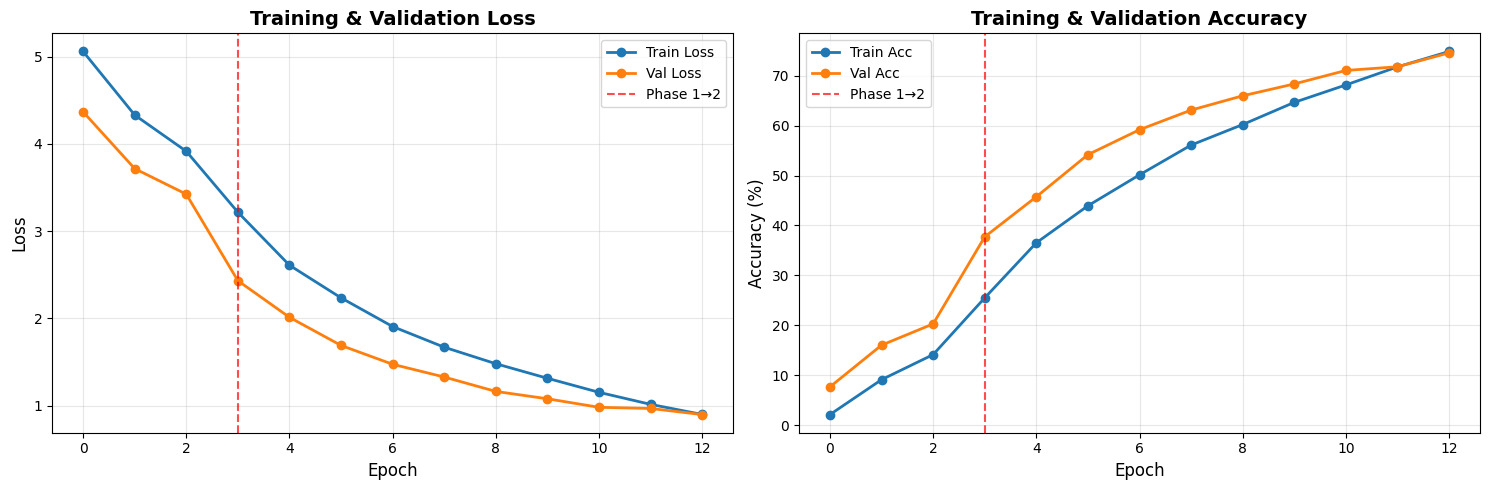

📊 Graphiques sauvegardés: models/efficientnet_classifier/training_curves.png

🏆 Meilleure Val Accuracy: 74.55%
📍 Atteinte à l'epoch: 13


In [15]:
# Courbes d'apprentissage
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='o')
axes[0].axvline(x=CONFIG['phase1_epochs'], color='red', linestyle='--', 
                label='Phase 1→2', alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2, marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2, marker='o')
axes[1].axvline(x=CONFIG['phase1_epochs'], color='red', linestyle='--',
                label='Phase 1→2', alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Graphiques sauvegardés: {MODELS_DIR / 'training_curves.png'}")

# Afficher stats
best_val_acc = max(history['val_acc'])
best_epoch = history['val_acc'].index(best_val_acc)
print(f"\n🏆 Meilleure Val Accuracy: {best_val_acc:.2f}%")
print(f"📍 Atteinte à l'epoch: {best_epoch + 1}")

In [16]:
best_val_acc = max(history['val_acc'])
print(f'🏆 Meilleure Accuracy: {best_val_acc:.2f}%')

with open(MODELS_DIR / 'class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

print('✅ Modèle sauvegardé')

🏆 Meilleure Accuracy: 74.55%
✅ Modèle sauvegardé
